In [1]:
# Support vector machine
# Linear SVM classisfication

'''LinearSVC class regularizes the bias term, so you should center the training set first by subtracting its mean.
This is automatic if you scale the data using the StandardScaler.

C = 1, hyperparameter that controls the balance between keeping the street as large as possible and limiting the margin violations.

hinge = loss function used in SVMs to train the model. It is well suited for linear SVM classification.
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()

iris.keys()

X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris-Virginica

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge")),
])

svm_clf.fit(X, y)

svm_clf.predict([[5.5, 1.7]])



array([1.])

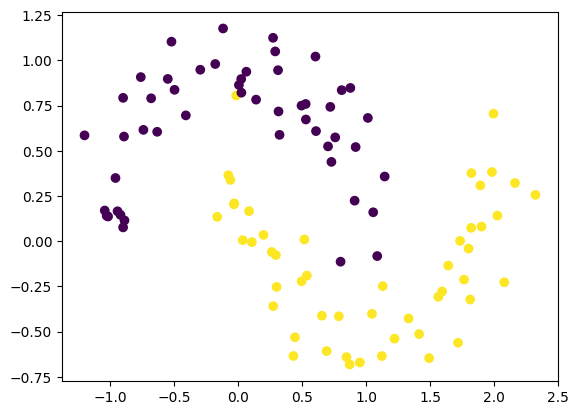

/home/borse_saurabh/ros2_ws/ws_machinel/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


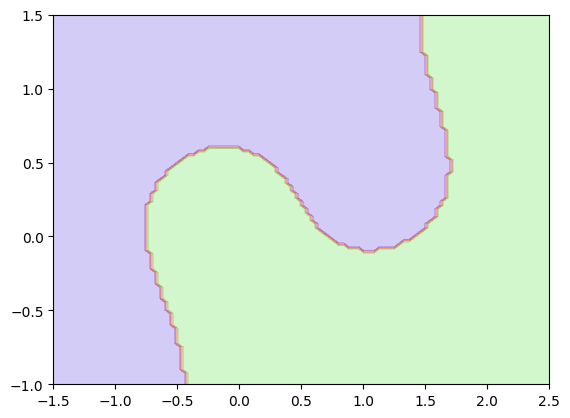

In [2]:
# Nonlinear SVM Classification
# LinearSVC with polynomial feature transformation

from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge"))
])

polynomial_svm_clf.fit(X, y)

# PLot the decision boundary along with data points

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])

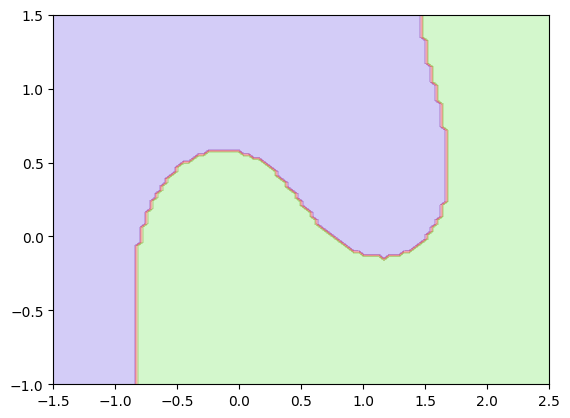

In [3]:
# Nonlinear SVM Classification using Polynomial Kernel

from sklearn.svm import SVC

poly_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
])

poly_kernel_svm_clf.fit(X, y)

plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])

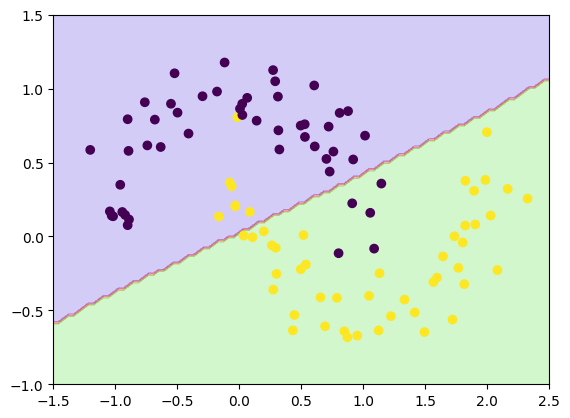

'Highret the gamma, the narrower the bell-shaped curve. \nThis makes the decision boundary more irregular, wiggling around individual instances. \nConversely, a small gamma value makes the bell-shaped curve wider, so instances have a larger range of influence, and the decision boundary ends up smoother. \nSo gamma acts like a regularization hyperparameter: if your model is overfitting, you should reduce it, and if it is underfitting, you should increase it (similar to the C hyperparameter).\n'

In [9]:
# Nonlinear SVM Classification using Gaussian RBF Kernel

rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", gamma=0.1, C=0.001))
])

rbf_kernel_svm_clf.fit(X, y)

plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

'''Highret the gamma, the narrower the bell-shaped curve. 
This makes the decision boundary more irregular, wiggling around individual instances. 
Conversely, a small gamma value makes the bell-shaped curve wider, so instances have a larger range of influence, and the decision boundary ends up smoother. 
So gamma acts like a regularization hyperparameter: if your model is overfitting, you should reduce it, and if it is underfitting, you should increase it (similar to the C hyperparameter).
'''

In [11]:
# SVM Regression
# Plot the data points
from sklearn.svm import LinearSVR

np.random.seed(42)
m = 50
X = 2 * np.random.rand(m, 1)
y = (4 + 3 * X + np.random.randn(m, 1)).ravel()

svm_reg = LinearSVR(epsilon=1.5)
svm_reg.fit(X, y)
svm_reg.predict([[1.5]])

# SVM Regression using Polynomial Kernel

from sklearn.svm import SVR

svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1)

svm_poly_reg.fit(X, y)
svm_poly_reg.predict([[1.5]])



array([8.32246495])